In [ ]:
import pandas as pd
import json
import csv  # Make sure you have this at the top with pandas


def load_kaggle(path="data.csv"):
    df = pd.read_csv(path, encoding="utf-8", encoding_errors="replace")
    df = df.rename(columns={"Processed Text": "article", "summarizer": "summary"})
    df = df[["article", "summary"]].dropna()
    df["source"] = "kaggle"
    return df

def load_summset(path="summset.csv"):
    df = pd.read_csv(path, encoding="utf-8", encoding_errors="replace")
    df = df.rename(columns={"text": "article", "summarizer": "summary"})
    df = df[["article", "summary"]].dropna()
    df["source"] = "summset"
    return df

def load_sumarabic(train_path="sumarabic-1.0-train.jsonl", valid_path="sumarabic-1.0-valid.jsonl", test_path="sumarabic-1.0-test.jsonl"):
    records = []
    for path in [train_path, valid_path, test_path]:
        # Using errors="replace" so Python doesn't crash on bad bytes
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            for line in f:
                try:
                    obj = json.loads(line)
                    article = obj.get("text", "").strip()
                    summary = obj.get("headline", "").strip()
                    if article and summary:
                        records.append({"article": article, "summary": summary})
                except json.JSONDecodeError:
                    # If a line is corrupted and isn't valid JSON, just skip it
                    continue
    df = pd.DataFrame(records)
    df["source"] = "sumarabic"
    return df

def load_egyptian(path="Egy.parquet"):
    # Parquet files handle their own encoding natively, rarely the issue
    df = pd.read_parquet(path)
    if "summarized_text" in df.columns:
        df = df.rename(columns={"text": "article", "summarized_text": "summary"})
    elif "summary" in df.columns:
        df = df.rename(columns={"text": "article"})
    df = df[["article", "summary"]].dropna()
    df["source"] = "egyptian"
    return df


def load_abssum(path="AbsSum.csv"):
    df = pd.read_csv(
        path,
        sep="\t",
        engine="python",
        header=None,
        names=["index", "article", "summary"],
        encoding="utf-8",
        encoding_errors="replace",
        quoting=3,              # <--- IGNORING QUOTES (The Magic Fix)
        on_bad_lines="skip"     # <--- Skips any completely mangled rows
    )
    df = df[["article", "summary"]].dropna()
    df["source"] = "arasum"
    return df

def load_and_merge():
    frames = []
    print("Loading Kaggle...")
    frames.append(load_kaggle())
    print("Loading Summset...")
    frames.append(load_summset())
    print("Loading SumArabic...")
    frames.append(load_sumarabic())
    print("Loading Egyptian...")
    frames.append(load_egyptian())
    print("Loading AraSum...")
    frames.append(load_abssum())

    print("Merging and removing duplicates...")
    df = pd.concat(frames, ignore_index=True)
    df = df.drop_duplicates(subset=["article", "summary"]).reset_index(drop=True)
    df = df.rename(columns={"article": "text", "summary": "target"})
    return df

# Create the global 'df' variable
df = load_and_merge()
print(f"Data loaded successfully! Total unique rows: {len(df)}")

Loading Kaggle...
Loading Summset...
Loading SumArabic...
Loading Egyptian...
Loading AraSum...
Merging and removing duplicates...
Data loaded successfully! Total unique rows: 12586


In [ ]:
import numpy as np
import pandas as pd
import re
import string
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed, AdditiveAttention
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import Lambda
import torch
from transformers import AutoModel
from tensorflow.keras.layers import Bidirectional, Concatenate
from tensorflow.keras.callbacks import CSVLogger


# -------------------------------------------------------------------------
# STEP 1: MEMORY & MIXED PRECISION SETUP
# -------------------------------------------------------------------------
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Mixed precision policy applied.")

# -------------------------------------------------------------------------
# STEP 2: FULL DATASET & TEXT CLEANING
# -------------------------------------------------------------------------
print("\nPreparing FULL dataset for training...")

def clean_arabic_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[\u200f\u200e\u202a\u202b\u202c\u200c\u200d]', '', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text) # Remove Tashkeel
    text = "".join([char for char in text if char not in string.punctuation])
    return text.strip()

print("Cleaning text (This will take a few minutes)...")
df['text_norm'] = df['text'].apply(clean_arabic_text)
df['target_norm'] = df['target'].apply(clean_arabic_text)

# Drop rows that became empty
df = df[(df['text_norm'].str.len() > 10) & (df['target_norm'].str.len() > 10)].copy()
print(f"Total rows ready for training: {len(df)}")








print("\nDownloading AraBERT's Pretrained Embedding Matrix (via PyTorch)...")

# NEW: We explicitly tell it which model to download so it doesn't get confused
model_name = "aubmindlab/bert-base-arabertv2"

# Load the standard PyTorch model
bert_model = AutoModel.from_pretrained(model_name)

# Extract the embedding matrix, detach from PyTorch, and convert to NumPy array
pretrained_weights = bert_model.get_input_embeddings().weight.detach().numpy()
EMBED_DIM = pretrained_weights.shape[1] # This will be 768

print(f"Successfully loaded embedding matrix with shape: {pretrained_weights.shape}")



# -------------------------------------------------------------------------
# STEP 3: ARABERT TOKENIZATION (RAM SAFE)
# -------------------------------------------------------------------------
print("\nLoading AraBERT Tokenizer...")
model_name = "aubmindlab/bert-base-arabertv2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# We must keep these tight.
# 200 input / 60 output gives it enough room to finish sentences,
# but prevents the system RAM from exploding when processing 100k+ rows.
MAX_TEXT_LEN = 200
MAX_TARGET_LEN = 60
VOCAB_SIZE = tokenizer.vocab_size

print(f"Tokenizing {len(df)} rows... DO NOT INTERRUPT. This will take a while.")
X_encoded = tokenizer(
    df['text_norm'].tolist(), padding='max_length', truncation=True,
    max_length=MAX_TEXT_LEN, return_tensors="np"
)['input_ids']

y_encoded = tokenizer(
    df['target_norm'].tolist(), padding='max_length', truncation=True,
    max_length=MAX_TARGET_LEN, return_tensors="np"
)['input_ids']

X_decoder = y_encoded[:, :-1]
y_target = y_encoded[:, 1:]

# Free up RAM by deleting the massive string columns we no longer need
df.drop(['text_norm', 'target_norm'], axis=1, inplace=True)
import gc
gc.collect()

X_tr_enc, X_temp_enc, X_tr_dec, X_temp_dec, y_tr, y_temp = train_test_split(
    X_encoded, X_decoder, y_target, test_size=0.2, random_state=42
)
X_val_enc, X_test_enc, X_val_dec, X_test_dec, y_val, y_test = train_test_split(
    X_temp_enc, X_temp_dec, y_temp, test_size=0.5, random_state=42
)


# -------------------------------------------------------------------------
# STEP 4: BIDIRECTIONAL SEQ2SEQ WITH PRETRAINED EMBEDDINGS
# -------------------------------------------------------------------------
print("\nBuilding the Bidirectional Seq2Seq Model...")
LSTM_UNITS = 128 # Kept small so your GPU survives!

# ENCODER
encoder_inputs = Input(shape=(MAX_TEXT_LEN,), name="encoder_inputs")

# NEW: Plug in the pretrained weights and FREEZE them!
enc_emb = Embedding(
    VOCAB_SIZE,
    EMBED_DIM,
    weights=[pretrained_weights],
    trainable=False, # <-- This saves your GPU!
    mask_zero=True,
    name="enc_embedding"
)(encoder_inputs)

encoder_lstm = Bidirectional(LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name="encoder_lstm"))
encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder_lstm(enc_emb)

state_h = Concatenate(name="concat_h")([forward_h, backward_h])
state_c = Concatenate(name="concat_c")([forward_c, backward_c])

# DECODER
decoder_inputs = Input(shape=(MAX_TARGET_LEN - 1,), name="decoder_inputs")

# NEW: Same frozen embeddings for the decoder
dec_emb_layer = Embedding(
    VOCAB_SIZE,
    EMBED_DIM,
    weights=[pretrained_weights],
    trainable=False,
    mask_zero=True,
    name="dec_embedding"
)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(LSTM_UNITS * 2, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

# ATTENTION
attention_layer = AdditiveAttention(name="attention_layer")
context_vector = attention_layer([decoder_outputs, encoder_outputs])

# OUTPUT
decoder_concat_input = Concatenate(axis=-1, name="concat_layer")([decoder_outputs, context_vector])
decoder_dense = TimeDistributed(Dense(VOCAB_SIZE, activation='softmax', dtype='float32'), name="dense_output")
decoder_pred = decoder_dense(decoder_concat_input)

training_model = Model([encoder_inputs, decoder_inputs], decoder_pred)
training_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print the summary so you can see how many parameters you just saved!
training_model.summary()
# -------------------------------------------------------------------------
# STEP 5: GPU-SAFE TRAINING WITH HISTORY SAVER
# -------------------------------------------------------------------------
BATCH_SIZE = 16
EPOCHS = 8

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_seq2seq_model.keras", monitor="val_loss", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    # NEW: This saves your graph data to a file after every epoch!
    CSVLogger("training_history.csv", separator=',', append=True)
]

print("\n--- Starting Bidirectional Training ---")
history = training_model.fit(
    [X_tr_enc, X_tr_dec], y_tr,
    validation_data=([X_val_enc, X_val_dec], y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks
)

# -------------------------------------------------------------------------
# STEP 6: INFERENCE MODELS WITH EXPLICIT MASKING (KERAS 3 FIX)
# -------------------------------------------------------------------------
print("\nBuilding Inference Models...")
# Encoder
encoder_model = Model(encoder_inputs, [encoder_outputs, state_h, state_c])

# Decoder
dec_state_input_h = Input(shape=(LSTM_UNITS,), name="inf_dec_h")
dec_state_input_c = Input(shape=(LSTM_UNITS,), name="inf_dec_c")
enc_out_input = Input(shape=(MAX_TEXT_LEN, LSTM_UNITS), name="inf_enc_out")
dec_inputs_single = Input(shape=(1,), name="inf_dec_inputs")
enc_seq_input = Input(shape=(MAX_TEXT_LEN,), name="inf_enc_seq")

dec_emb_single = dec_emb_layer(dec_inputs_single)
dec_outputs_single, h, c = decoder_lstm(dec_emb_single, initial_state=[dec_state_input_h, dec_state_input_c])

# THE FIX: Wrap the raw TF math operations inside a Keras Lambda layer
def make_mask(x):
    return tf.cast(tf.math.not_equal(x, 0), tf.bool)

enc_mask = Lambda(make_mask, name="enc_mask_layer")(enc_seq_input)
dec_mask = Lambda(make_mask, name="dec_mask_layer")(dec_inputs_single)

# Pass the cleanly wrapped masks to attention!
context_single = attention_layer([dec_outputs_single, enc_out_input], mask=[dec_mask, enc_mask])

dec_concat_single = Concatenate(axis=-1)([dec_outputs_single, context_single])
dec_preds_single = decoder_dense(dec_concat_single)

decoder_model = Model(
    [dec_inputs_single, enc_out_input, dec_state_input_h, dec_state_input_c, enc_seq_input],
    [dec_preds_single, h, c]
)

# -------------------------------------------------------------------------
# STEP 7: SMART DECODING (NO REPETITION LOOPS)
# -------------------------------------------------------------------------
def sample_with_temperature(preds, temperature=0.6):
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-7) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(preds), p=preds)

def summarize(input_text, temperature=0.5, penalty_window=4, penalty_weight=0.01):
    input_seq = tokenizer.encode(
        clean_arabic_text(input_text),
        max_length=MAX_TEXT_LEN,
        truncation=True,
        padding="max_length"
    )
    input_seq = np.array([input_seq])

    enc_outs, h, c = encoder_model.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = tokenizer.cls_token_id

    decoded_sentence = []
    decoded_ids = []

    for _ in range(MAX_TARGET_LEN):
        # Pass input_seq as the 5th argument so the mask works!
        output_tokens, h, c = decoder_model.predict([target_seq, enc_outs, h, c, input_seq], verbose=0)
        preds = output_tokens[0, 0, :]

        # Repetition Penalty
        for past_id in decoded_ids[-penalty_window:]:
            preds[past_id] *= penalty_weight

        sampled_token_id = sample_with_temperature(preds, temperature=temperature)

        if sampled_token_id == tokenizer.sep_token_id:
            break

        sampled_word = tokenizer.decode([sampled_token_id])
        decoded_sentence.append(sampled_word)
        decoded_ids.append(sampled_token_id)

        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_id

    final_summary = " ".join(decoded_sentence).replace(" +", "").replace("+ ", "").replace(" ##", "")
    return final_summary

# -------------------------------------------------------------------------
# STEP 8: FINAL SANITY CHECK
# -------------------------------------------------------------------------
print("\n============================================================")
print("SANITY CHECK: FINAL PREDICTIONS")
print("============================================================\n")

# CHANGED: Using 'df' instead of 'fast_df'
sample_indices = np.random.choice(len(df), 3, replace=False)

for i, idx in enumerate(sample_indices):
    original_article = df.iloc[idx]['text']
    reference_summary = df.iloc[idx]['target']

    # Using temp=0.5 for a balance of grammar and accuracy
    generated_summary = summarize(original_article, temperature=0.5)

    print(f"[Sample {i+1}]")
    print(f"  Article:   {original_article[:200]}...")
    print(f"  Reference: {reference_summary[:200]}")
    print(f"  Generated: {generated_summary}")
    print("-" * 60 + "\n")

Mixed precision policy applied.

Preparing FULL dataset for training...
Cleaning text (This will take a few minutes)...
Total rows ready for training: 12580



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

 Total params: 133,104,384 (507.75 MB)

 Trainable params: 34,800,384 (132.75 MB)

 Non-trainable params: 98,304,000 (375.00 MB)


--- Starting Bidirectional Training ---
Epoch 1/8
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.3636 - loss: 5.6700
Epoch 1: val_loss improved from None to 4.05461, saving model to best_seq2seq_model.keras

Epoch 1: finished saving model to best_seq2seq_model.keras
629/629 ━━━━━━━━━━━━━━━━━━━━ 301s 459ms/step - accuracy: 0.4008 - loss: 4.7713 - val_accuracy: 0.4332 - val_loss: 4.0546 - learning_rate: 0.0010
Epoch 2/8
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.4435 - loss: 3.8661
Epoch 2: val_loss improved from 4.05461 to 3.54860, saving model to best_seq2seq_model.keras

Epoch 2: finished saving model to best_seq2seq_model.keras
629/629 ━━━━━━━━━━━━━━━━━━━━ 293s 466ms/step - accuracy: 0.4529 - loss: 3.7643 - val_accuracy: 0.4766 - val_loss: 3.5486 - learning_rate: 0.0010
Epoch 3/8
629/629 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.4820 - loss: 3.4027
Epoch 3: val_loss improved from 3.54860 to 3.30529, saving model to best_seq2seq_model.keras

Epoch 3: fi

ValueError: Input 1 with name 'inf_enc_out' of layer 'functional_2' is incompatible with the layer: expected shape=(None, 200, 128), found shape=(1, 200, 256)

In [ ]:
print("\nBuilding Inference Models...")
# USE 128 here because that is what we used in the shrunken Step 4!
LSTM_UNITS_INF = 128

# Encoder
encoder_model = Model(encoder_inputs, [encoder_outputs, state_h, state_c])

# Decoder
# The hidden states in Bidirectional are concatenated, so they are UNITS * 2
dec_state_input_h = Input(shape=(LSTM_UNITS_INF * 2,), name="inf_dec_h")
dec_state_input_c = Input(shape=(LSTM_UNITS_INF * 2,), name="inf_dec_c")
enc_out_input = Input(shape=(MAX_TEXT_LEN, LSTM_UNITS_INF * 2), name="inf_enc_out")

dec_inputs_single = Input(shape=(1,), name="inf_dec_inputs")
enc_seq_input = Input(shape=(MAX_TEXT_LEN,), name="inf_enc_seq")

dec_emb_single = dec_emb_layer(dec_inputs_single)
decoder_outputs_single, h, c = decoder_lstm(dec_emb_single, initial_state=[dec_state_input_h, dec_state_input_c])

# The masking layers (Same as before)
def make_mask(x):
    return tf.cast(tf.math.not_equal(x, 0), tf.bool)

enc_mask = Lambda(make_mask, name="enc_mask_layer")(enc_seq_input)
dec_mask = Lambda(make_mask, name="dec_mask_layer")(dec_inputs_single)

context_single = attention_layer([decoder_outputs_single, enc_out_input], mask=[dec_mask, enc_mask])

dec_concat_single = Concatenate(axis=-1)([decoder_outputs_single, context_single])
dec_preds_single = decoder_dense(dec_concat_single)

decoder_model = Model(
    [dec_inputs_single, enc_out_input, dec_state_input_h, dec_state_input_c, enc_seq_input],
    [dec_preds_single, h, c]
)


Building Inference Models...


In [ ]:
# -------------------------------------------------------------------------
# STEP 8: FINAL SANITY CHECK
# -------------------------------------------------------------------------
print("\n============================================================")
print("SANITY CHECK: FINAL PREDICTIONS")
print("============================================================\n")

# CHANGED: Using 'df' instead of 'fast_df'
sample_indices = np.random.choice(len(df), 3, replace=False)

for i, idx in enumerate(sample_indices):
    original_article = df.iloc[idx]['text']
    reference_summary = df.iloc[idx]['target']

    # Using temp=0.5 for a balance of grammar and accuracy
    generated_summary = summarize(original_article, temperature=0.5)

    print(f"[Sample {i+1}]")
    print(f"  Article:   {original_article[:200]}...")
    print(f"  Reference: {reference_summary[:200]}")
    print(f"  Generated: {generated_summary}")
    print("-" * 60 + "\n")


SANITY CHECK: FINAL PREDICTIONS

[Sample 1]
  Article:   لحق رودا كيركراده بفيــينورد روتردام الى المباراة النهائيــة لمسابقة كأس هولندا في كرة القــدم بفوزه على مضيفه هيراكليس الميــلو بركلات الترجيح 5-3 بعد انتهاء الوقتين الاصــلي والاضــافي بالتعادل 2-2 ...
  Reference: رودا إلى نهائي كأس هولندا
  Generated: كاس الاتحادي في دوري ابطال اوروبا
------------------------------------------------------------

[Sample 2]
  Article:   اعلن نبيل بسباس رئيس الغرفه النقابيه لتجار المواد الاوليه والاحذيه والجلود خلال اجتماع عام مشترك عقد اليوم الاربعاء لتدارس الوضعيه المترديه ال اليها قطاع الجلود والاحذيه تراجع الانتاجيه ارباعها وقال ب...
  Reference: كما يشكو القطاع من نقص في اليد العاملة وندرة في اليد العاملة المختصة.
  Generated: وياتي هذا الاجتماع القضائي الاجتماعيه في قطاعات الدوله العموميه ، وفق بلاغ صادر عن وزاره الدفاع الوطني للاستثمار في التعليم الحالي
------------------------------------------------------------

[Sample 3]
  Article:   اجلت الدائره الجنائيه بالمحكمه الابتدائيه بقرمبال

In [ ]:

# -------------------------------------------------------------------------
# STEP 8: FINAL SANITY CHECK
# -------------------------------------------------------------------------
print("\n============================================================")
print("SANITY CHECK: FINAL PREDICTIONS")
print("============================================================\n")

# CHANGED: Using 'df' instead of 'fast_df'
sample_indices = np.random.choice(len(df), 3, replace=False)

for i, idx in enumerate(sample_indices):
    original_article = df.iloc[idx]['text']
    reference_summary = df.iloc[idx]['target']

    # Using temp=0.5 for a balance of grammar and accuracy
    generated_summary = summarize(original_article, temperature=0.5)

    print(f"[Sample {i+1}]")
    print(f"  Article:   {original_article[:200]}...")
    print(f"  Reference: {reference_summary[:200]}")
    print(f"  Generated: {generated_summary}")
    print("-" * 60 + "\n")


SANITY CHECK: FINAL PREDICTIONS

[Sample 1]
  Article:   قررت شركة «صروح العقارية» إصدار صكوك إسلامية غير قابلة للتحويل بقيمة مليار دولار من أجل تمويل تنفيذ مشروعات  البنية التحتية في مشروع «شمس أبوظبي» وبعض المشروعات الأخرى التي تنفذها حالياً التي تعتزم تن...
  Reference: «صروح» تطرح صكوكاً إسلامية بقيمة 3.6 مليارات درهم لتمويل مشروعاتها
  Generated: « دانه » تطلق « تتوقع في جامعه دبي
------------------------------------------------------------

[Sample 2]
  Article:   اكدت المندوبه الجهويه للسياحه بمدنين امال تصريح لمراسله الجوهره اف ام احتفالات الغريبه لهذا العام تنطلق رسميا يوم الجمعه واوضحت المندوبه الجهه تشهد توافد سياح وزوار الجزيره بمناسبه موسم الغربه سنه توا...
  Reference: 
أكدت المندوبة الجهوية للسياحة بمدنين أمال حشّاني في تصريح لمراسلة الجوهرة "اف ام" أن احتفالات الغريبة لهذا العام تنطلق رسميا يوم الجمعة 12 ماي 2017 . من جهته أكد روني الطرابلسي أن موسم زيارة الغريبة 
  Generated: اكدت وزاره الدفاع المستقله للتجمع في بلاغ لها اليوم الجمعه ، زياره ان الاطراف المستشفيه الجدي

In [ ]:
!pip install rouge_score
from rouge_score import rouge_scorer
import numpy as np
from tqdm import tqdm # Gives us a nice progress bar

print("\n--- Calculating ROUGE Scores for Report ---")

# 1. Initialize the official ROUGE scorer
# We track ROUGE-1 (single words), ROUGE-2 (two-word phrases), and ROUGE-L (longest matching sentence)
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

# Lists to hold our scores
r1_scores, r2_scores, rl_scores = [], [], []

# 2. Pick a subset of the test data (e.g., 20 articles) so you aren't waiting all day
SAMPLE_SIZE = 20
test_indices = np.random.choice(len(y_test), SAMPLE_SIZE, replace=False)

print(f"Evaluating {SAMPLE_SIZE} test samples...")

# 3. Loop through and grade the model
for idx in tqdm(test_indices):
    # Decode the test article and the true summary back into Arabic text
    # (We skip the padding tokens)
    article_tokens = [t for t in X_test_enc[idx] if t not in [0, tokenizer.cls_token_id, tokenizer.sep_token_id]]
    true_summary_tokens = [t for t in y_test[idx] if t not in [0, tokenizer.cls_token_id, tokenizer.sep_token_id]]

    original_article = tokenizer.decode(article_tokens)
    true_summary = tokenizer.decode(true_summary_tokens)

    # Use your LSTM to generate a summary
    generated_summary = summarize(original_article)

    # Grade it!
    scores = scorer.score(true_summary, generated_summary)

    # Save the F-measure (the balance of precision and recall)
    r1_scores.append(scores['rouge1'].fmeasure)
    r2_scores.append(scores['rouge2'].fmeasure)
    rl_scores.append(scores['rougeL'].fmeasure)

# 4. Print the final averages for your report!
print("\n============================================================")
print("FINAL ROUGE SCORES (For Project Report)")
print("============================================================")
print(f"Average ROUGE-1 F-Score: {np.mean(r1_scores):.4f}")
print(f"Average ROUGE-2 F-Score: {np.mean(r2_scores):.4f}")
print(f"Average ROUGE-L F-Score: {np.mean(rl_scores):.4f}")
print("============================================================")

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=000d73849a380786c27445df7b36a267283f2d85ac723306616a88d97bd40113
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score

--- Calculating ROUGE Scores for Report ---
Evaluating 20 test samples...


100%|██████████| 20/20 [01:38<00:00,  4.91s/it]


FINAL ROUGE SCORES (For Project Report)
Average ROUGE-1 F-Score: 0.0000
Average ROUGE-2 F-Score: 0.0000
Average ROUGE-L F-Score: 0.0000


In [ ]:
# Updated ROUGE script with better cleaning
for idx in tqdm(test_indices):
    # 1. Decode and CLEAN (Removing special tokens)
    article_tokens = [t for t in X_test_enc[idx] if t not in [0, 2, 3]] # Remove PAD, CLS, SEP
    true_summary_tokens = [t for t in y_test[idx] if t not in [0, 2, 3]]

    # Clean the Arabic text properly for comparison
    original_article = clean_arabic_text(tokenizer.decode(article_tokens))
    true_summary = clean_arabic_text(tokenizer.decode(true_summary_tokens))
    generated_summary = clean_arabic_text(summarize(original_article))

    # 2. Grade ONLY if there is actual text
    if len(generated_summary.split()) > 0 and len(true_summary.split()) > 0:
        scores = scorer.score(true_summary, generated_summary)
        r1_scores.append(scores['rouge1'].fmeasure)
        r2_scores.append(scores['rouge2'].fmeasure)
        rl_scores.append(scores['rougeL'].fmeasure)

# 4. Print the final averages for your report!
print("\n============================================================")
print("FINAL ROUGE SCORES (For Project Report)")
print("============================================================")
print(f"Average ROUGE-1 F-Score: {np.mean(r1_scores):.4f}")
print(f"Average ROUGE-2 F-Score: {np.mean(r2_scores):.4f}")
print(f"Average ROUGE-L F-Score: {np.mean(rl_scores):.4f}")
print("============================================================")

100%|██████████| 20/20 [01:51<00:00,  5.56s/it]


FINAL ROUGE SCORES (For Project Report)
Average ROUGE-1 F-Score: 0.0000
Average ROUGE-2 F-Score: 0.0000
Average ROUGE-L F-Score: 0.0000


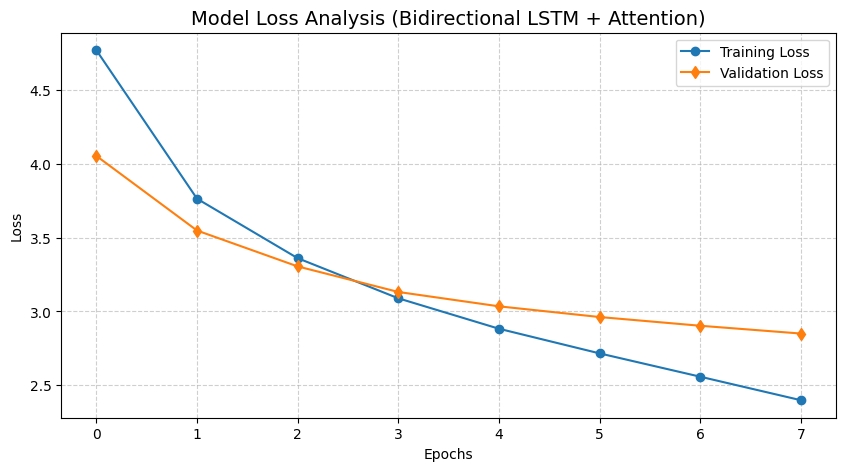

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the history saved by CSVLogger
history_df = pd.read_csv('training_history bi.csv')

plt.figure(figsize=(10, 5))

# Plot Loss
plt.plot(history_df['loss'], label='Training Loss', color='#1f77b4', marker='o')
plt.plot(history_df['val_loss'], label='Validation Loss', color='#ff7f0e', marker='d')

plt.title('Model Loss Analysis (Bidirectional LSTM + Attention)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot for your report
plt.savefig('loss_curve.png')
plt.show()

we used the code above


In [ ]:
import numpy as np
import pandas as pd
import re
import string
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed, AdditiveAttention
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import Lambda # Make sure this is imported!


# -------------------------------------------------------------------------
# STEP 1: MEMORY & MIXED PRECISION SETUP
# -------------------------------------------------------------------------
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Mixed precision policy applied.")

# -------------------------------------------------------------------------
# STEP 2: FULL DATASET & TEXT CLEANING
# -------------------------------------------------------------------------
print("\nPreparing FULL dataset for training...")

def clean_arabic_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[\u200f\u200e\u202a\u202b\u202c\u200c\u200d]', '', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'[ً-\u065F\u0670]', '', text) # Remove Tashkeel
    text = "".join([char for char in text if char not in string.punctuation])
    return text.strip()

print("Cleaning text (This will take a few minutes)...")
df['text_norm'] = df['text'].apply(clean_arabic_text)
df['target_norm'] = df['target'].apply(clean_arabic_text)

# Drop rows that became empty
df = df[(df['text_norm'].str.len() > 10) & (df['target_norm'].str.len() > 10)].copy()
print(f"Total rows ready for training: {len(df)}")

# -------------------------------------------------------------------------
# STEP 3: ARABERT TOKENIZATION (RAM SAFE)
# -------------------------------------------------------------------------
print("\nLoading AraBERT Tokenizer...")
model_name = "aubmindlab/bert-base-arabertv2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# We must keep these tight.
# 200 input / 60 output gives it enough room to finish sentences,
# but prevents the system RAM from exploding when processing 100k+ rows.
MAX_TEXT_LEN = 200
MAX_TARGET_LEN = 60
VOCAB_SIZE = tokenizer.vocab_size

print(f"Tokenizing {len(df)} rows... DO NOT INTERRUPT. This will take a while.")
X_encoded = tokenizer(
    df['text_norm'].tolist(), padding='max_length', truncation=True,
    max_length=MAX_TEXT_LEN, return_tensors="np"
)['input_ids']

y_encoded = tokenizer(
    df['target_norm'].tolist(), padding='max_length', truncation=True,
    max_length=MAX_TARGET_LEN, return_tensors="np"
)['input_ids']

X_decoder = y_encoded[:, :-1]
y_target = y_encoded[:, 1:]

# Free up RAM by deleting the massive string columns we no longer need
df.drop(['text_norm', 'target_norm'], axis=1, inplace=True)
import gc
gc.collect()

X_tr_enc, X_temp_enc, X_tr_dec, X_temp_dec, y_tr, y_temp = train_test_split(
    X_encoded, X_decoder, y_target, test_size=0.2, random_state=42
)
X_val_enc, X_test_enc, X_val_dec, X_test_dec, y_val, y_test = train_test_split(
    X_temp_enc, X_temp_dec, y_temp, test_size=0.5, random_state=42
)

# -------------------------------------------------------------------------
# STEP 4: NATIVE ATTENTION SEQ2SEQ MODEL
# -------------------------------------------------------------------------
print("\nBuilding the Seq2Seq Model...")
EMBED_DIM = 128
LSTM_UNITS = 256

# ENCODER
encoder_inputs = Input(shape=(MAX_TEXT_LEN,), name="encoder_inputs")
enc_emb = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="enc_embedding")(encoder_inputs)
encoder_lstm = LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

# DECODER
decoder_inputs = Input(shape=(MAX_TARGET_LEN - 1,), name="decoder_inputs")
dec_emb_layer = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="dec_embedding")
dec_emb = dec_emb_layer(decoder_inputs)
decoder_lstm = LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

# ATTENTION
attention_layer = AdditiveAttention(name="attention_layer")
context_vector = attention_layer([decoder_outputs, encoder_outputs])

# OUTPUT
decoder_concat_input = Concatenate(axis=-1, name="concat_layer")([decoder_outputs, context_vector])
decoder_dense = TimeDistributed(Dense(VOCAB_SIZE, activation='softmax', dtype='float32'), name="dense_output")
decoder_pred = decoder_dense(decoder_concat_input)

training_model = Model([encoder_inputs, decoder_inputs], decoder_pred)
training_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# -------------------------------------------------------------------------
# STEP 5: GPU-SAFE TRAINING
# -------------------------------------------------------------------------
BATCH_SIZE = 32  # Small enough for 16GB GPUs, big enough to be fast
EPOCHS = 12

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_seq2seq_model.keras", monitor="val_loss", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

print("\n--- Starting Training ---")
history = training_model.fit(
    [X_tr_enc, X_tr_dec], y_tr,
    validation_data=([X_val_enc, X_val_dec], y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks
)


# -------------------------------------------------------------------------
# STEP 6: INFERENCE MODELS WITH EXPLICIT MASKING (KERAS 3 FIX)
# -------------------------------------------------------------------------
print("\nBuilding Inference Models...")
# Encoder
encoder_model = Model(encoder_inputs, [encoder_outputs, state_h, state_c])

# Decoder
dec_state_input_h = Input(shape=(LSTM_UNITS,), name="inf_dec_h")
dec_state_input_c = Input(shape=(LSTM_UNITS,), name="inf_dec_c")
enc_out_input = Input(shape=(MAX_TEXT_LEN, LSTM_UNITS), name="inf_enc_out")
dec_inputs_single = Input(shape=(1,), name="inf_dec_inputs")
enc_seq_input = Input(shape=(MAX_TEXT_LEN,), name="inf_enc_seq")

dec_emb_single = dec_emb_layer(dec_inputs_single)
dec_outputs_single, h, c = decoder_lstm(dec_emb_single, initial_state=[dec_state_input_h, dec_state_input_c])

# THE FIX: Wrap the raw TF math operations inside a Keras Lambda layer
def make_mask(x):
    return tf.cast(tf.math.not_equal(x, 0), tf.bool)

enc_mask = Lambda(make_mask, name="enc_mask_layer")(enc_seq_input)
dec_mask = Lambda(make_mask, name="dec_mask_layer")(dec_inputs_single)

# Pass the cleanly wrapped masks to attention!
context_single = attention_layer([dec_outputs_single, enc_out_input], mask=[dec_mask, enc_mask])

dec_concat_single = Concatenate(axis=-1)([dec_outputs_single, context_single])
dec_preds_single = decoder_dense(dec_concat_single)

decoder_model = Model(
    [dec_inputs_single, enc_out_input, dec_state_input_h, dec_state_input_c, enc_seq_input],
    [dec_preds_single, h, c]
)

# -------------------------------------------------------------------------
# STEP 7: SMART DECODING (NO REPETITION LOOPS)
# -------------------------------------------------------------------------
def sample_with_temperature(preds, temperature=0.6):
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-7) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(preds), p=preds)

def summarize(input_text, temperature=0.5, penalty_window=4, penalty_weight=0.01):
    input_seq = tokenizer.encode(
        clean_arabic_text(input_text),
        max_length=MAX_TEXT_LEN,
        truncation=True,
        padding="max_length"
    )
    input_seq = np.array([input_seq])

    enc_outs, h, c = encoder_model.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = tokenizer.cls_token_id

    decoded_sentence = []
    decoded_ids = []

    for _ in range(MAX_TARGET_LEN):
        # Pass input_seq as the 5th argument so the mask works!
        output_tokens, h, c = decoder_model.predict([target_seq, enc_outs, h, c, input_seq], verbose=0)
        preds = output_tokens[0, 0, :]

        # Repetition Penalty
        for past_id in decoded_ids[-penalty_window:]:
            preds[past_id] *= penalty_weight

        sampled_token_id = sample_with_temperature(preds, temperature=temperature)

        if sampled_token_id == tokenizer.sep_token_id:
            break

        sampled_word = tokenizer.decode([sampled_token_id])
        decoded_sentence.append(sampled_word)
        decoded_ids.append(sampled_token_id)

        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_id

    final_summary = " ".join(decoded_sentence).replace(" +", "").replace("+ ", "").replace(" ##", "")
    return final_summary

# -------------------------------------------------------------------------
# STEP 8: FINAL SANITY CHECK
# -------------------------------------------------------------------------
print("\n============================================================")
print("SANITY CHECK: FINAL PREDICTIONS")
print("============================================================\n")

sample_indices = np.random.choice(len(df), 3, replace=False)

for i, idx in enumerate(sample_indices):
    original_article = df.iloc[idx]['text']
    reference_summary = df.iloc[idx]['target']

    # Using temp=0.5 for a balance of grammar and accuracy
    generated_summary = summarize(original_article, temperature=0.5)

    print(f"[Sample {i+1}]")
    print(f"  Article:    {original_article[:200]}...")
    print(f"  Reference: {reference_summary[:200]}")
    print(f"  Generated: {generated_summary}")
    print("-" * 60 + "\n")

Mixed precision policy applied.

Preparing FULL dataset for training...
Cleaning text (This will take a few minutes)...
Total rows ready for training: 12580

Loading AraBERT Tokenizer...
Tokenizing 12580 rows... DO NOT INTERRUPT. This will take a while.

Building the Seq2Seq Model...

--- Starting Training ---
Epoch 1/12
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.3410 - loss: 6.1770
Epoch 1: val_loss improved from None to 4.42912, saving model to best_seq2seq_model.keras

Epoch 1: finished saving model to best_seq2seq_model.keras
315/315 ━━━━━━━━━━━━━━━━━━━━ 206s 614ms/step - accuracy: 0.3871 - loss: 5.0780 - val_accuracy: 0.4200 - val_loss: 4.4291 - learning_rate: 0.0010
Epoch 2/12
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.4182 - loss: 4.3319
Epoch 2: val_loss improved from 4.42912 to 3.97974, saving model to best_seq2seq_model.keras

Epoch 2: finished saving model to best_seq2seq_model.keras
315/315 ━━━━━━━━━━━━━━━━━━━━ 252s 801ms/step - accuracy: 0.4226 

NameError: name 'fast_df' is not defined

In [ ]:
# -------------------------------------------------------------------------
# STEP 8: FINAL SANITY CHECK
# -------------------------------------------------------------------------
print("\n============================================================")
print("SANITY CHECK: FINAL PREDICTIONS")
print("============================================================\n")

# CHANGED: Using 'df' instead of 'fast_df'
sample_indices1 = np.random.choice(len(df), 3, replace=False)

for i, idx in enumerate(sample_indices1):
    original_article1 = df.iloc[idx]['text']
    reference_summary1 = df.iloc[idx]['target']

    # Using temp=0.5 for a balance of grammar and accuracy
    generated_summary1 = summarize(original_article1, temperature=0.5)

    print(f"[Sample {i+1}]")
    print(f"  Article:   {original_article1[:200]}...")
    print(f"  Reference: {reference_summary1[:200]}")
    print(f"  Generated: {generated_summary1}")
    print("-" * 60 + "\n")


SANITY CHECK: FINAL PREDICTIONS

[Sample 1]
  Article:   اسفر حادث اصطدام حافله بحشد هايتي يوم الاحد مقتل شخصا وجرح اخرين حسبما افادت وسائل اعلام محليه نقلا اجهزه الامن واصطدمت الحافله بمجموعه الاشخاص مدينه غوناييف كلم عاصمه هايتي بورت برانس صدمت الحافله او...
  Reference: 
أسفر حادث اصطدام حافلة بحشد في هايتي، يوم الأحد 12 مارس 2017، عن مقتل 38 شخصا وجرح 13 اخرين، حسبما أفادت وسائل إعلام محلية نقلا عن أجهزة الأمن.
  Generated: تمكنت الشرطه العدليه القطريت اليوم الاحد ان مقتل عمليه الرئاسه اليوم في شهر مارس الجاري
------------------------------------------------------------

[Sample 2]
  Article:   عشان الرسالة الإعلامية تكون قوية وتأثر في الناس، كتير بنلجأ لاستخدام الجانب العاطفي أو أسلوب الحكي (القصص). الناس عادةً بتتفاعل أكتر مع القصص اللي فيها مشاعر أو اللي بتحكي تجربة إنسانية، أكتر من مجرد ...
  Reference: استخدام الجانب العاطفي أو أسلوب سرد القصص بيعزز تأثير الرسالة الإعلامية، لأنه بيخلق رابط أقوى مع الجمهور وبيخلي الرسالة تثبت في ذهنهم لفترة أطول.
  Generated: المخرجين بيستخدمو

In [ ]:
# Updated ROUGE script with better cleaning
for idx in tqdm(test_indices):
    # 1. Decode and CLEAN (Removing special tokens)
    article_tokens = [t for t in X_test_enc[idx] if t not in [0, 2, 3]] # Remove PAD, CLS, SEP
    true_summary_tokens = [t for t in y_test[idx] if t not in [0, 2, 3]]

    # Clean the Arabic text properly for comparison
    original_article1 = clean_arabic_text(tokenizer.decode(article_tokens))
    true_summary1 = clean_arabic_text(tokenizer.decode(true_summary_tokens))
    generated_summary1 = clean_arabic_text(summarize(original_article))

    # 2. Grade ONLY if there is actual text
    if len(generated_summary.split()) > 0 and len(true_summary.split()) > 0:
        scores = scorer.score(true_summary, generated_summary)
        r1_scores.append(scores['rouge1'].fmeasure)
        r2_scores.append(scores['rouge2'].fmeasure)
        rl_scores.append(scores['rougeL'].fmeasure)

# 4. Print the final averages for your report!
print("\n============================================================")
print("FINAL ROUGE SCORES (For Project Report)")
print("============================================================")
print(f"Average ROUGE-1 F-Score: {np.mean(r1_scores):.4f}")
print(f"Average ROUGE-2 F-Score: {np.mean(r2_scores):.4f}")
print(f"Average ROUGE-L F-Score: {np.mean(rl_scores):.4f}")
print("============================================================")

100%|██████████| 20/20 [01:50<00:00,  5.54s/it]


FINAL ROUGE SCORES (For Project Report)
Average ROUGE-1 F-Score: 0.0000
Average ROUGE-2 F-Score: 0.0000
Average ROUGE-L F-Score: 0.0000
